# Time Series & Trend Analysis

This notebook demonstrates advanced T-SQL patterns for time series analysis using the AdventureWorksDW2022 data warehouse.

**Questions covered:**
5. Running Total of Sales by Month
6. Month-over-Month Sales Growth (with Date Spine)
7. 3-Month Moving Average
8. Year-to-Date (YTD) Sales

## Setup

In [1]:
import urllib
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Database connection - adjust server name as needed
server = 'localhost'
database = 'AdventureWorksDW2022'
conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'
conn_url = f'mssql+pyodbc:///?odbc_connect={urllib.parse.quote_plus(conn_str)}'
engine = create_engine(conn_url)
print('Connected to AdventureWorksDW2022')

Connected to AdventureWorksDW2022


---
## Q5: Running Total of Sales by Month

**Business Question:** Calculate a running total of internet sales revenue by month, partitioned by product category.

**Key Techniques:**
- `SUM() OVER (PARTITION BY ... ORDER BY ...)` for cumulative sum
- Default window frame (RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)

In [2]:
q5_sql = """
WITH MonthlySales AS (
    SELECT 
        dd.CalendarYear,
        dd.MonthNumberOfYear,
        dd.EnglishMonthName AS Month,
        cat.ProductCategoryKey AS CategoryID,
        cat.EnglishProductCategoryName AS Category,
        SUM(fis.SalesAmount) AS MonthlySales
    FROM dbo.FactInternetSales fis
    INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
    INNER JOIN dbo.DimProduct p ON fis.ProductKey = p.ProductKey
    INNER JOIN dbo.DimProductSubcategory sub ON p.ProductSubcategoryKey = sub.ProductSubcategoryKey
    INNER JOIN dbo.DimProductCategory cat ON sub.ProductCategoryKey = cat.ProductCategoryKey
    GROUP BY dd.CalendarYear, dd.MonthNumberOfYear, dd.EnglishMonthName, cat.ProductCategoryKey, cat.EnglishProductCategoryName
),
CategoryRunningTotal AS (
    SELECT 
        CalendarYear,
        MonthNumberOfYear,
        Month,
        CategoryID,
        Category,
        MonthlySales,
        SUM(MonthlySales) OVER (PARTITION BY CategoryID ORDER BY CalendarYear, MonthNumberOfYear) AS RunningTotal
    FROM MonthlySales
)
SELECT 
    CalendarYear,
    MonthNumberOfYear,
    Month,
    Category,
    MonthlySales,
    RunningTotal
FROM CategoryRunningTotal
ORDER BY Category, CalendarYear, MonthNumberOfYear
"""

df_q5 = pd.read_sql(q5_sql, engine)
df_q5.head(15)

,CalendarYear,MonthNumberOfYear,Month,Category,MonthlySales,RunningTotal
0,2012,12,December,Accessories,"2,147.08","2,147.08"
1,2013,1,January,Accessories,"19,049.71","21,196.79"
2,2013,2,February,Accessories,"46,246.09","67,442.88"
3,2013,3,March,Accessories,"55,339.21","122,782.09"
4,2013,4,April,Accessories,"51,721.76","174,503.85"
5,2013,5,May,Accessories,"57,876.93","232,380.78"
6,2013,6,June,Accessories,"62,526.89","294,907.67"
7,2013,7,July,Accessories,"58,001.76","352,909.43"
8,2013,8,August,Accessories,"59,736.99","412,646.42"
9,2013,9,September,Accessories,"58,523.23","471,169.65"


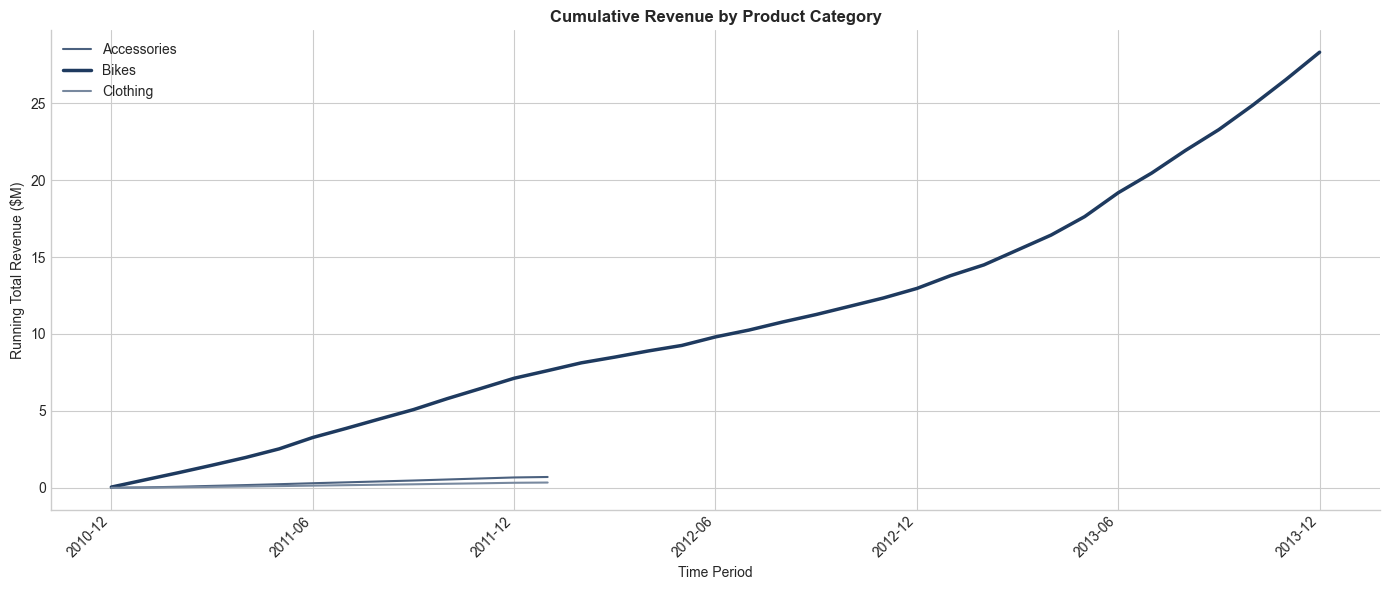

In [3]:
# Visualization: Running Total by Category
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']
HIGHLIGHT_COLOR = THEME_COLORS[0]
MUTED_COLOR = THEME_COLORS[4]

fig, ax = plt.subplots(figsize=(14, 6))

categories = df_q5['Category'].unique()
top_category = df_q5.groupby('Category')['RunningTotal'].max().idxmax()

# Rank categories by total revenue and assign colors
category_totals = df_q5.groupby('Category')['RunningTotal'].max().sort_values(ascending=False)
category_colors = {cat: THEME_COLORS[i] if i < len(THEME_COLORS) else THEME_COLORS[-1] 
                   for i, cat in enumerate(category_totals.index)}

for category in categories:
    cat_data = df_q5[df_q5['Category'] == category]
    color = category_colors[category]
    linewidth = 2.5 if category == top_category else 1.5
    ax.plot(range(len(cat_data)), cat_data['RunningTotal'] / 1_000_000, 
            label=category, linewidth=linewidth, color=color)

ax.set_xlabel('Time Period')
ax.set_ylabel('Running Total Revenue ($M)')
ax.set_title('Cumulative Revenue by Product Category', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show fewer x-tick labels
tick_positions = range(0, len(df_q5[df_q5['Category'] == 'Bikes']), 6)
tick_labels = [f"{df_q5[df_q5['Category'] == 'Bikes'].iloc[i]['CalendarYear']}-{df_q5[df_q5['Category'] == 'Bikes'].iloc[i]['MonthNumberOfYear']:02d}" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## Q6: Month-over-Month Sales Growth (Date Spine Pattern)

**Business Question:** Calculate the percentage change in sales revenue compared to the previous month for each territory, including months with zero sales.

**Key Techniques:**
- **Date Spine** via `CROSS JOIN` to ensure continuous time series
- `LEFT JOIN` to preserve months with no sales
- `COALESCE()` to handle NULL as zero
- `LAG()` for month-over-month comparison

In [4]:
q6_sql = """
WITH DateSpine AS (
    -- Create all distinct year-month combinations within the sales date range
    SELECT DISTINCT 
        CalendarYear,
        MonthNumberOfYear AS MonthID,
        EnglishMonthName AS Month
    FROM dbo.DimDate
    WHERE DateKey BETWEEN 
        (SELECT MIN(OrderDateKey) FROM dbo.FactInternetSales) AND
        (SELECT MAX(OrderDateKey) FROM dbo.FactInternetSales)
),
TerritoryMonthJoin AS (
    -- Cross join: all Territory x Month combinations
    SELECT 
        ds.CalendarYear,
        ds.MonthID,
        ds.Month,
        st.SalesTerritoryCountry AS Country
    FROM DateSpine ds
    CROSS JOIN (
        SELECT DISTINCT SalesTerritoryCountry
        FROM dbo.DimSalesTerritory
        WHERE SalesTerritoryCountry IS NOT NULL AND SalesTerritoryCountry <> 'NA'
    ) st
),
TerritoryMonthlySales AS (
    -- Left Join to preserve all months, including $0 sales
    SELECT
        tmj.CalendarYear,
        tmj.MonthID,
        tmj.Month,
        tmj.Country,
        COALESCE(sales.MonthlySales, 0) AS MonthlySales
    FROM TerritoryMonthJoin tmj
    LEFT JOIN (
        SELECT 
            st.SalesTerritoryCountry AS Country,
            dd.CalendarYear,
            dd.MonthNumberOfYear AS MonthID,
            SUM(fis.SalesAmount) AS MonthlySales
        FROM dbo.FactInternetSales fis
        INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
        INNER JOIN dbo.DimSalesTerritory st ON fis.SalesTerritoryKey = st.SalesTerritoryKey
        GROUP BY st.SalesTerritoryCountry, dd.CalendarYear, dd.MonthNumberOfYear
    ) sales
        ON tmj.Country = sales.Country
        AND tmj.CalendarYear = sales.CalendarYear
        AND tmj.MonthID = sales.MonthID
),
MoMGrowth AS (
    SELECT 
        CalendarYear,
        MonthID,
        Month,
        Country,
        MonthlySales,
        LAG(MonthlySales) OVER (PARTITION BY Country ORDER BY CalendarYear, MonthID) AS PreviousMonthSales,
        MonthlySales - LAG(MonthlySales) OVER (PARTITION BY Country ORDER BY CalendarYear, MonthID) AS MoMChange
    FROM TerritoryMonthlySales
)
SELECT 
    CalendarYear,
    MonthID,
    Month,
    Country,
    MonthlySales,
    PreviousMonthSales,
    MoMChange,
    CASE WHEN PreviousMonthSales = 0 THEN NULL 
         ELSE MoMChange / PreviousMonthSales * 100 END AS MoMGrowthRate
FROM MoMGrowth
ORDER BY Country, CalendarYear, MonthID
"""

df_q6 = pd.read_sql(q6_sql, engine)
df_q6.head(20)

,CalendarYear,MonthID,Month,Country,MonthlySales,PreviousMonthSales,MoMChange,MoMGrowthRate
0,2010,12,December,Australia,"20,909.78",NaN,NaN,NaN
1,2011,1,January,Australia,"207,130.29","20,909.78","186,220.51",890.59
2,2011,2,February,Australia,"204,151.12","207,130.29","-2,979.17",-1.43
3,2011,3,March,Australia,"177,393.50","204,151.12","-26,757.62",-13.10
4,2011,4,April,Australia,"214,593.39","177,393.50","37,199.89",20.97
5,2011,5,May,Australia,"217,636.82","214,593.39","3,043.43",1.41
6,2011,6,June,Australia,"267,232.29","217,636.82","49,595.46",22.78
7,2011,7,July,Australia,"223,109.11","267,232.29","-44,123.18",-16.51
8,2011,8,August,Australia,"190,022.33","223,109.11","-33,086.78",-14.82
9,2011,9,September,Australia,"218,157.64","190,022.33","28,135.31",14.80


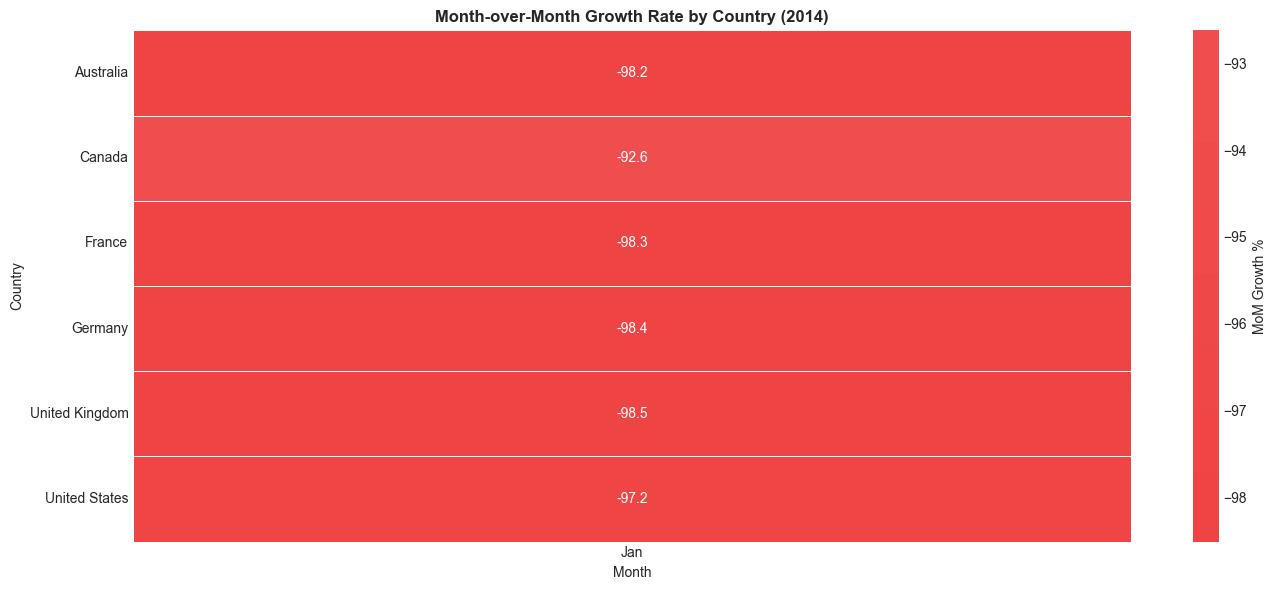

In [5]:
# Visualization: MoM Growth Heatmap for a single year
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']

year_filter = df_q6['CalendarYear'].max()
df_year = df_q6[df_q6['CalendarYear'] == year_filter]

pivot = df_year.pivot(index='Country', columns='MonthID', values='MoMGrowthRate')
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 6))

# Professional blue-grey colormap using theme colors
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('theme_diverging', 
    ['#ef4444', '#ffffff', THEME_COLORS[0]], N=256)

sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, center=0, ax=ax, 
            cbar_kws={'label': 'MoM Growth %'}, linewidths=0.5, linecolor='white')

ax.set_title(f'Month-over-Month Growth Rate by Country ({year_filter})', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

---
## Q7: 3-Month Moving Average

**Business Question:** Compute a 3-month moving average of sales to smooth out seasonal fluctuations.

**Key Techniques:**
- `AVG() OVER (ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)` for trailing average
- Window frame specification for precise row boundaries

In [6]:
q7_sql = """
WITH MonthlySales AS (
    SELECT 
        dd.CalendarYear,
        dd.MonthNumberOfYear AS MonthID,
        dd.EnglishMonthName AS Month,
        SUM(fis.SalesAmount) AS MonthlySales
    FROM dbo.FactInternetSales fis
    INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
    GROUP BY dd.CalendarYear, dd.MonthNumberOfYear, dd.EnglishMonthName
),
MovingAverage AS (
    SELECT
        CalendarYear,
        MonthID,
        Month,
        MonthlySales,
        AVG(MonthlySales) OVER (ORDER BY CalendarYear, MonthID ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS MovingAvg3Month,
        COUNT(MonthID) OVER (ORDER BY CalendarYear, MonthID ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS NumOfMonths
    FROM MonthlySales
)
SELECT
    CalendarYear,
    MonthID,
    Month,
    MonthlySales,
    MovingAvg3Month,
    NumOfMonths
FROM MovingAverage
ORDER BY CalendarYear, MonthID
"""

df_q7 = pd.read_sql(q7_sql, engine)
df_q7

,CalendarYear,MonthID,Month,MonthlySales,MovingAvg3Month,NumOfMonths
0,2010,12,December,"43,421.04","43,421.04",1
1,2011,1,January,"469,823.91","256,622.48",2
2,2011,2,February,"466,334.90","326,526.62",3
3,2011,3,March,"485,198.66","473,785.83",3
4,2011,4,April,"502,073.85","484,535.80",3
5,2011,5,May,"561,681.48","516,317.99",3
6,2011,6,June,"737,839.82","600,531.71",3
7,2011,7,July,"596,746.56","632,089.28",3
8,2011,8,August,"614,557.94","649,714.77",3
9,2011,9,September,"603,083.50","604,796.00",3


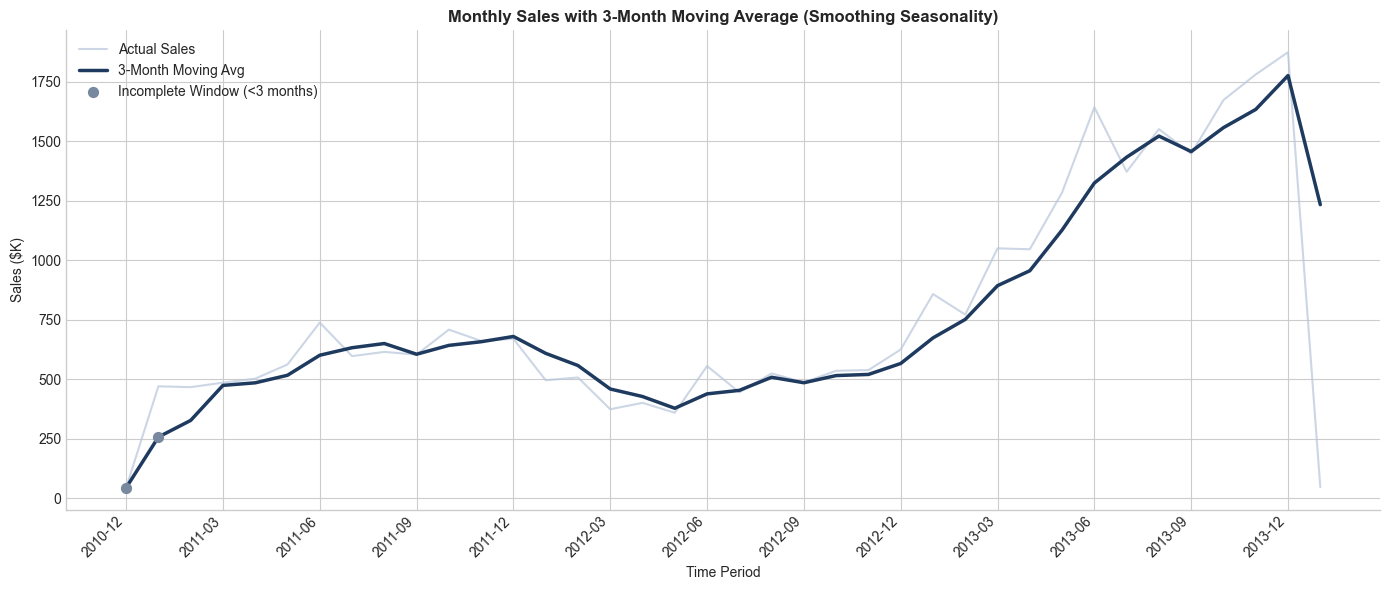

In [7]:
# Visualization: Actual vs 3-Month Moving Average
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']
HIGHLIGHT_COLOR = THEME_COLORS[0]
MUTED_COLOR = THEME_COLORS[4]

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(df_q7))
ax.plot(x, df_q7['MonthlySales'] / 1000, label='Actual Sales', alpha=0.7, linewidth=1.5, color=MUTED_COLOR)
ax.plot(x, df_q7['MovingAvg3Month'] / 1000, label='3-Month Moving Avg', linewidth=2.5, color=HIGHLIGHT_COLOR)

# Highlight where moving average doesn't have full 3 months
incomplete = df_q7[df_q7['NumOfMonths'] < 3]
ax.scatter(incomplete.index, incomplete['MovingAvg3Month'] / 1000, color=THEME_COLORS[2], s=50, 
           label='Incomplete Window (<3 months)', zorder=5)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales ($K)')
ax.set_title('Monthly Sales with 3-Month Moving Average (Smoothing Seasonality)', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-axis labels
tick_positions = range(0, len(df_q7), 3)
tick_labels = [f"{df_q7.iloc[i]['CalendarYear']}-{df_q7.iloc[i]['MonthID']:02d}" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## Q8: Year-to-Date (YTD) Sales

**Business Question:** Calculate YTD sales for each product, resetting at the start of each calendar year.

**Key Techniques:**
- `SUM() OVER (PARTITION BY year, product ORDER BY month)` for YTD accumulation
- Partition boundary resets the running total each year

In [8]:
q8_sql = """
WITH MonthlySales AS (
    SELECT 
        dd.CalendarYear,
        dd.MonthNumberOfYear AS MonthID,
        dd.EnglishMonthName AS Month,
        p.ProductKey,
        p.EnglishProductName AS Product,
        SUM(fis.SalesAmount) AS MonthlySales
    FROM dbo.FactInternetSales fis
    INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
    INNER JOIN dbo.DimProduct p ON fis.ProductKey = p.ProductKey
    GROUP BY dd.CalendarYear, dd.MonthNumberOfYear, dd.EnglishMonthName, p.ProductKey, p.EnglishProductName
),
YTDSales AS (
    SELECT 
        CalendarYear,
        MonthID,
        Month,
        ProductKey,
        Product,
        MonthlySales,
        SUM(MonthlySales) OVER (PARTITION BY CalendarYear, ProductKey ORDER BY MonthID) AS YTDSales
    FROM MonthlySales
)
SELECT
    CalendarYear,
    MonthID,
    Month,
    Product,
    MonthlySales,
    YTDSales
FROM YTDSales
ORDER BY Product, CalendarYear, MonthID
"""

df_q8 = pd.read_sql(q8_sql, engine)
df_q8.head(20)

,CalendarYear,MonthID,Month,Product,MonthlySales,YTDSales
0,2012,12,December,All-Purpose Bike Stand,159.00,159.00
1,2013,1,January,All-Purpose Bike Stand,"1,272.00","1,272.00"
2,2013,2,February,All-Purpose Bike Stand,"2,544.00","3,816.00"
3,2013,3,March,All-Purpose Bike Stand,"3,180.00","6,996.00"
4,2013,4,April,All-Purpose Bike Stand,"4,134.00","11,130.00"
5,2013,5,May,All-Purpose Bike Stand,"3,816.00","14,946.00"
6,2013,6,June,All-Purpose Bike Stand,"3,816.00","18,762.00"
7,2013,7,July,All-Purpose Bike Stand,"2,703.00","21,465.00"
8,2013,8,August,All-Purpose Bike Stand,"2,862.00","24,327.00"
9,2013,9,September,All-Purpose Bike Stand,"2,862.00","27,189.00"


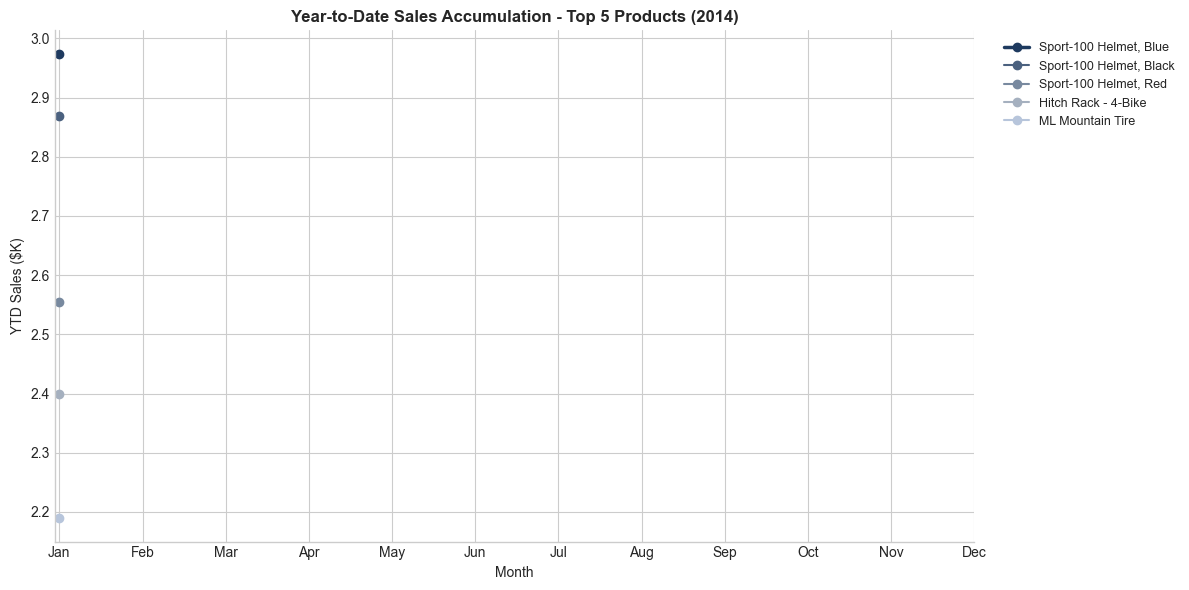

In [9]:
# Visualization: YTD Sales for Top 5 Products (Latest Year)
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']

latest_year = df_q8['CalendarYear'].max()
top_products = df_q8[df_q8['CalendarYear'] == latest_year].groupby('Product')['YTDSales'].max().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for i, product in enumerate(top_products):
    prod_data = df_q8[(df_q8['Product'] == product) & (df_q8['CalendarYear'] == latest_year)]
    color = THEME_COLORS[i] if i < len(THEME_COLORS) else THEME_COLORS[-1]
    linewidth = 2.5 if i == 0 else 1.5
    ax.plot(prod_data['MonthID'], prod_data['YTDSales'] / 1000, marker='o', 
            label=product[:30], linewidth=linewidth, color=color)

ax.set_xlabel('Month')
ax.set_ylabel('YTD Sales ($K)')
ax.set_title(f'Year-to-Date Sales Accumulation - Top 5 Products ({latest_year})', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

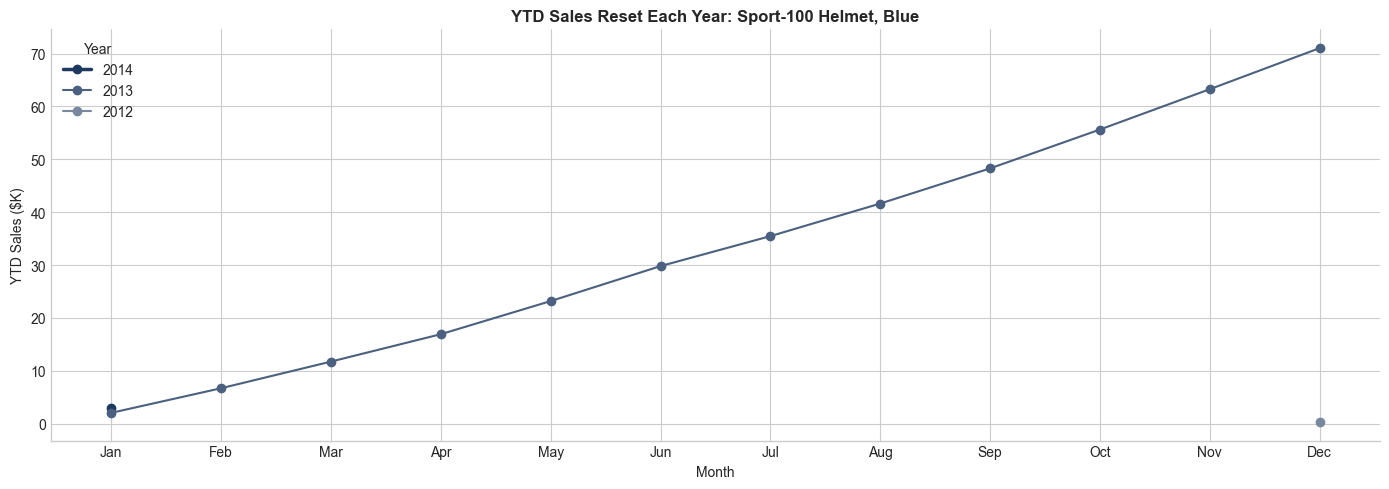

In [10]:
# Show YTD reset across years for one product
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']

sample_product = top_products[0]
sample_data = df_q8[df_q8['Product'] == sample_product]

fig, ax = plt.subplots(figsize=(14, 5))

years = sorted(sample_data['CalendarYear'].unique())
latest_year = max(years)

# Assign colors based on recency (most recent = primary)
for i, year in enumerate(reversed(years)):
    year_data = sample_data[sample_data['CalendarYear'] == year]
    color = THEME_COLORS[i] if i < len(THEME_COLORS) else THEME_COLORS[-1]
    linewidth = 2.5 if year == latest_year else 1.5
    ax.plot(year_data['MonthID'], year_data['YTDSales'] / 1000, marker='o', 
            label=str(year), linewidth=linewidth, color=color)

ax.set_xlabel('Month')
ax.set_ylabel('YTD Sales ($K)')
ax.set_title(f'YTD Sales Reset Each Year: {sample_product[:50]}', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(title='Year')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Cleanup

In [11]:
engine.dispose()
print('Connection closed')

Connection closed
